# Stage 2 — Plain MAPPO (PAH OFF)

**Config:** 5 drones · moving targets · 5 obstacles · conflict graph ON · PAH OFF

**Why PAH OFF first:** If Stage 2 base fails, we know it's the config (not PAH).
Only after this run confirms convergence → create `kaggle_stage2_pah.ipynb`.

**Changes from Stage 1 (v4):**
| | Stage 1 (v4) | Stage 2 (this) |
|---|---|---|
| Drones | 3 | **5** |
| Obstacles | 0 | **5** |
| Targets | Static | **Moving (1 m/step)** |
| Conflict graph | OFF (obs=10) | **ON (obs=30)** |
| max_steps | 300 | **500** |
| total_episodes | 5000 | **8000** |
| PAH | OFF | **OFF (plain MAPPO)** |

In [1]:
# Cell 1 — Imports
import torch
import numpy as np
from scipy.optimize import linear_sum_assignment
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda


In [2]:
# Cell 2 — Conflict Graph
# Ported from code/algorithms/conflict_graph.py

import numpy as np

def _time_to_cpa(pos_i, pos_j, vel_i, vel_j):
    p = pos_i - pos_j
    v = vel_i - vel_j
    vv = np.dot(v, v)
    if vv < 1e-8:
        return np.inf
    return -np.dot(p, v) / vv

def _dist_at_cpa(pos_i, pos_j, vel_i, vel_j, horizon):
    p = pos_i - pos_j
    v = vel_i - vel_j
    vv = np.dot(v, v)
    if vv < 1e-8:
        return float(np.linalg.norm(p)), 0.0
    t_star = -np.dot(p, v) / vv
    t_clamped = float(np.clip(t_star, 0.0, horizon))
    return float(np.linalg.norm(p + v * t_clamped)), t_star

class ConflictGraph:
    K_NBR = 4

    def __init__(self, n_drones, horizon=3.0, d_danger=9.0):
        self.n      = n_drones
        self.H      = horizon
        self.d_dan  = d_danger
        self.adj    = np.zeros((n_drones, n_drones), dtype=bool)
        self.t_mat  = np.full((n_drones, n_drones), np.inf)

    def update(self, pos, vel):
        self.adj[:] = False
        self.t_mat[:] = np.inf
        for i in range(self.n):
            for j in range(i + 1, self.n):
                dcpa, t_star = _dist_at_cpa(pos[i], pos[j], vel[i], vel[j], self.H)
                self.t_mat[i, j] = self.t_mat[j, i] = t_star
                if dcpa < self.d_dan and 0.0 <= t_star <= self.H:
                    self.adj[i, j] = self.adj[j, i] = True

    def n_conflict(self, i):
        return int(self.adj[i].sum())

    def tau_collision(self, i):
        nbrs = np.where(self.adj[i])[0]
        if len(nbrs) == 0:
            return self.H
        return float(np.min(self.t_mat[i, nbrs]))

    def neighbor_obs(self, i, pos, vel):
        obs = np.zeros(self.K_NBR * 5, dtype=np.float32)
        nbrs = np.where(self.adj[i])[0]
        if len(nbrs) == 0:
            return obs
        order = np.argsort(self.t_mat[i, nbrs])
        nbrs  = nbrs[order]
        for slot, j in enumerate(nbrs[:self.K_NBR]):
            b = slot * 5
            obs[b:b+2]   = pos[j] - pos[i]
            obs[b+2:b+4] = vel[j] - vel[i]
            obs[b+4]     = 1.0
        return obs

In [3]:
# Cell 3 — Environment
# Changes from v4:
#   - Moving targets: target_vel initialized at reset, targets drift + bounce
#   - Conflict graph ON: obs_dim=30, all normalized in _obs()
#   - Hard collision termination (like Stage 1)
#   - episode_collision flag tracks cumulative collision for eval
#   - n_drones=5, n_obstacles=2 (curriculum)

import numpy as np
from scipy.optimize import linear_sum_assignment

K_NBR    = 4
BASE_DIM = 10
OBS_DIM  = BASE_DIM + K_NBR * 5  # 30

class MultiUAVEnv:
    def __init__(self, n_drones=5, n_obstacles=2, world_size=500.0,
                 max_speed=5.0, max_steps=500, collision_radius=3.0,
                 target_radius=25.0, success_bonus=20.0,
                 target_speed=1.0, seed=None):
        self.n         = n_drones
        self.n_obs     = n_obstacles
        self.W         = world_size
        self.max_sp    = max_speed
        self.max_steps = max_steps
        self.col_r     = collision_radius
        self.tgt_r     = target_radius
        self.bonus     = success_bonus
        self.tgt_speed = target_speed
        self.rng       = np.random.default_rng(seed)
        self.cg        = ConflictGraph(n_drones, horizon=3.0,
                                       d_danger=collision_radius * 3.0)
        self.obs_dim   = OBS_DIM
        self.act_dim   = 2

    def reset(self):
        self.t                  = 0
        self.collision_occurred = False
        all_pos = self._sample_non_overlapping(self.n * 2, self.col_r * 2)
        self.drone_pos  = all_pos[:self.n].copy()
        self.target_pos = all_pos[self.n:].copy()
        self.obstacle_pos = self._place_obstacles(
            np.concatenate([self.drone_pos, self.target_pos]), self.n_obs
        )
        self.drone_vel = np.zeros((self.n, 2), dtype=np.float32)
        angles = self.rng.uniform(0, 2 * np.pi, self.n)
        self.target_vel = (self.tgt_speed * np.stack(
            [np.cos(angles), np.sin(angles)], axis=1
        )).astype(np.float32)
        self.assignment = self._hungarian()
        self.cg.update(self.drone_pos, self.drone_vel)
        return self._obs()

    def step(self, actions):
        self.t += 1
        actions = np.clip(actions, -self.max_sp, self.max_sp)
        self.drone_vel = actions.astype(np.float32)
        self.drone_pos = np.clip(self.drone_pos + self.drone_vel, 0.0, self.W)

        self.target_pos = self.target_pos + self.target_vel
        for k in range(self.n):
            for dim in range(2):
                if self.target_pos[k, dim] < 10.0:
                    self.target_pos[k, dim] = 10.0
                    self.target_vel[k, dim] *= -1.0
                elif self.target_pos[k, dim] > self.W - 10.0:
                    self.target_pos[k, dim] = self.W - 10.0
                    self.target_vel[k, dim] *= -1.0

        self.assignment = self._hungarian()
        self.cg.update(self.drone_pos, self.drone_vel)

        rewards, r_mission, r_safety = self._rewards()
        all_reached   = self._all_reached()
        any_collision = self._any_collision()
        timeout       = self.t >= self.max_steps

        if any_collision:
            self.collision_occurred = True

        terminated = all_reached or any_collision
        truncated  = timeout

        if all_reached and self.bonus:
            rewards += self.bonus

        info = {
            'all_targets_reached': all_reached,
            'any_collision':       any_collision,
            'episode_collision':   self.collision_occurred,
            'r_mission':           r_mission,
            'r_safety':            r_safety,
        }
        return self._obs(), rewards, terminated, truncated, info

    def _obs(self):
        obs = np.zeros((self.n, self.obs_dim), dtype=np.float32)
        for i in range(self.n):
            rel = self.target_pos[self.assignment[i]] - self.drone_pos[i]
            cl  = self._clearances(i)
            base = np.concatenate([
                self.drone_pos[i] / self.W,
                self.drone_vel[i] / self.max_sp,
                rel               / self.W,
                cl,
            ])
            nbr = self.cg.neighbor_obs(i, self.drone_pos, self.drone_vel)
            for s in range(K_NBR):
                nbr[s*5 : s*5+2]   /= self.W
                nbr[s*5+2 : s*5+4] /= self.max_sp
            obs[i] = np.concatenate([base, nbr])
        return obs

    def _rewards(self):
        r_mission = np.zeros(self.n, dtype=np.float32)
        r_safety  = np.zeros(self.n, dtype=np.float32)
        d_danger  = self.col_r * 3.0
        zone_w    = d_danger - self.col_r
        for i in range(self.n):
            rel  = self.target_pos[self.assignment[i]] - self.drone_pos[i]
            dist = np.linalg.norm(rel)
            direction  = rel / (dist + 1e-6)
            r_progress = float(np.dot(self.drone_vel[i], direction) / self.max_sp)
            r_mission[i] = 0.4 * r_progress + 0.3 * (-dist / self.W)
            min_d = float('inf')
            for j in range(self.n):
                if j != i:
                    min_d = min(min_d, np.linalg.norm(self.drone_pos[i] - self.drone_pos[j]))
            for op in self.obstacle_pos:
                min_d = min(min_d, np.linalg.norm(self.drone_pos[i] - op))
            if min_d < self.col_r:
                r_safety[i] = -1.0
            elif min_d < d_danger:
                r_safety[i] = -((d_danger - min_d) / zone_w)
        rewards = r_mission + 0.3 * r_safety
        return rewards, r_mission, r_safety

    def _hungarian(self):
        cost = np.array([
            [np.linalg.norm(self.drone_pos[i] - self.target_pos[j])
             for j in range(self.n)]
            for i in range(self.n)
        ])
        _, col = linear_sum_assignment(cost)
        return col

    def _all_reached(self):
        return all(
            np.linalg.norm(self.drone_pos[i] - self.target_pos[self.assignment[i]]) <= self.tgt_r
            for i in range(self.n)
        )

    def _any_collision(self):
        for i in range(self.n):
            for j in range(self.n):
                if j != i and np.linalg.norm(self.drone_pos[i] - self.drone_pos[j]) < self.col_r:
                    return True
            for op in self.obstacle_pos:
                if np.linalg.norm(self.drone_pos[i] - op) < self.col_r:
                    return True
        return False

    def _clearances(self, i):
        pos = self.drone_pos[i]
        cl  = np.array([self.W - pos[1], pos[1], self.W - pos[0], pos[0]], dtype=np.float32)
        for op in self.obstacle_pos:
            diff = op - pos
            if diff[1] > 0: cl[0] = min(cl[0],  diff[1])
            else:           cl[1] = min(cl[1], -diff[1])
            if diff[0] > 0: cl[2] = min(cl[2],  diff[0])
            else:           cl[3] = min(cl[3], -diff[0])
        return cl / self.W

    def _sample_non_overlapping(self, n, min_dist):
        pts, attempts = [], 0
        while len(pts) < n:
            attempts += 1
            if attempts > 10000:
                raise RuntimeError('World too crowded.')
            c = self.rng.uniform(10.0, self.W - 10.0, 2)
            if not any(np.linalg.norm(c - p) < min_dist for p in pts):
                pts.append(c)
        return np.array(pts, dtype=np.float32)

    def _place_obstacles(self, existing, n_obs, max_tries=1000):
        if n_obs <= 0:
            return np.zeros((0, 2), dtype=np.float32)
        r_min = 2.0 * self.col_r
        placed = []
        for _ in range(n_obs):
            for _ in range(max_tries):
                c = self.rng.uniform(10.0, self.W - 10.0, 2)
                if any(np.linalg.norm(c - o) < r_min for o in placed): continue
                if any(np.linalg.norm(c - p) < self.col_r for p in existing): continue
                placed.append(c)
                break
            else:
                break
        return np.array(placed, dtype=np.float32) if placed else np.zeros((0, 2), dtype=np.float32)

print('obs_dim = {}  (10 base + {}x5 conflict neighbors, normalized)'.format(OBS_DIM, K_NBR))

obs_dim = 30  (10 base + 4x5 conflict neighbors, normalized)


In [4]:
# Cell 4 — MAPPO (Actor + Critic + Buffer + Agent)
#
# FIXED 2026-09-16 (Manish): the previous version of this cell broke the
# centralized-critic / per-drone-credit design that Stage 1 (and
# code/algorithms/mappo.py) already validated:
#   - Critic(obs_dim) evaluated PER DRONE on its own local observation
#     (not a centralized critic on the joint/global state)
#   - rews.mean() / vals.mean() / lps.mean() collapsed all 5 drones into
#     ONE averaged number per step, then the SAME advantage was applied to
#     every drone's gradient regardless of which drone actually did well or
#     badly. No drone could ever learn "my action was good/bad" from that —
#     the training signal was pure noise, which is why log_std kept exploding
#     no matter what else was changed (obstacle count, termination, target
#     radius). See sessions/2026-09-15.md Part 12 for the full diagnosis.
#
# This cell now matches code/algorithms/mappo.py's validated design exactly:
# ONE centralized critic on the flattened joint state, PER-DRONE rewards and
# log-probs kept separate all the way through GAE and the PPO update.
# Only change vs code/algorithms/mappo.py: no PAH branch (plain MAPPO here;
# Actor.forward() keeps the log_std clamp added during Stage 2 debugging).

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))

    def forward(self, x):
        h       = self.net(x)
        mu      = self.mu_head(h)
        # Clamp kept from Stage 2 debugging (2026-09-15) as a safety net —
        # caps max entropy at ~5.8 even if the training signal is briefly
        # unbalanced. With the credit-assignment bug fixed, this should
        # rarely bind — if it never binds during a real run, it can be
        # removed later, but it does no harm left in place.
        log_std = self.log_std.clamp(-4.0, 1.5)
        std     = log_std.exp().expand_as(mu)
        return Normal(mu, std)

    def get_action(self, obs):
        dist   = self(obs)
        action = dist.sample()
        log_p  = dist.log_prob(action).sum(-1)
        return action, log_p

    def evaluate_action(self, obs, action):
        dist    = self(obs)
        log_p   = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_p, entropy


class Critic(nn.Module):
    """Centralized critic — sees the FLATTENED JOINT state of all drones,
    outputs ONE value per timestep (not one per drone)."""
    def __init__(self, global_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


class RolloutBuffer:
    """Stores per-drone rewards/log-probs and ONE global value per step —
    nothing here is averaged across drones."""
    def __init__(self, n_drones):
        self.n_drones = n_drones
        self.clear()

    def clear(self):
        self.obs, self.acts, self.rews = [], [], []
        self.vals, self.lps, self.dones = [], [], []

    def add(self, obs, act, rew, val, lp, done):
        # obs:(n,D) act:(n,2) rew:(n,) val:float lp:(n,) done:bool
        self.obs.append(obs.copy())
        self.acts.append(act.copy())
        self.rews.append(rew.copy())
        self.vals.append(float(val))
        self.lps.append(lp.copy())
        self.dones.append(bool(done))

    def __len__(self):
        return len(self.rews)

    def compute_gae(self, last_val, gamma, lam):
        T = len(self.rews)
        n = self.n_drones
        rewards = np.array(self.rews,  dtype=np.float32)   # (T, n)
        values  = np.array(self.vals,  dtype=np.float32)   # (T,)
        dones   = np.array(self.dones, dtype=np.float32)   # (T,)

        adv      = np.zeros((T, n), dtype=np.float32)
        last_gae = np.zeros(n, dtype=np.float32)
        for t in reversed(range(T)):
            next_val = last_val if t == T - 1 else values[t + 1]
            mask     = 1.0 - dones[t]
            delta    = rewards[t] + gamma * next_val * mask - values[t]
            last_gae = delta + gamma * lam * mask * last_gae
            adv[t]   = last_gae
        returns = adv + values[:, np.newaxis]   # (T, n)
        return adv, returns


class MAPPOAgent:
    def __init__(self, n_drones, obs_dim, act_dim, lr=3e-4, gamma=0.99, lam=0.95,
                 clip_eps=0.2, vf_coef=0.5, ent_coef=0.003,
                 n_epochs=10, batch_size=64):
        self.n_drones = n_drones
        self.gamma, self.lam           = gamma, lam
        self.clip_eps                  = clip_eps
        self.vf_coef, self.ent_coef    = vf_coef, ent_coef
        self.n_epochs, self.batch_size = n_epochs, batch_size

        global_dim  = n_drones * obs_dim
        self.actor  = Actor(obs_dim, act_dim).to(DEVICE)
        self.critic = Critic(global_dim).to(DEVICE)
        self.opt    = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )

    @torch.no_grad()
    def get_actions(self, obs):
        """obs: (n_drones, obs_dim) -> actions (n,2), log_probs (n,), value (float, ONE for the team)."""
        obs_t         = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
        action_t, lp_t = self.actor.get_action(obs_t)

        global_state = obs_t.flatten().unsqueeze(0)          # (1, n*obs_dim)
        value        = self.critic(global_state).item()      # single scalar

        return action_t.cpu().numpy(), lp_t.cpu().numpy(), value

    def update(self, buffer, last_obs):
        last_obs_t = torch.tensor(last_obs, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            last_val = self.critic(last_obs_t.flatten().unsqueeze(0)).item()

        adv_np, ret_np = buffer.compute_gae(last_val, self.gamma, self.lam)  # (T,n) each

        obs_np = np.array(buffer.obs,  dtype=np.float32)   # (T,n,D)
        act_np = np.array(buffer.acts, dtype=np.float32)   # (T,n,2)
        lp_np  = np.array(buffer.lps,  dtype=np.float32)   # (T,n)
        T, N, D = obs_np.shape

        adv_t = torch.tensor(adv_np, dtype=torch.float32, device=DEVICE)
        ret_t = torch.tensor(ret_np, dtype=torch.float32, device=DEVICE)
        adv_flat_all = adv_t.reshape(-1)
        adv_t = (adv_t - adv_flat_all.mean()) / (adv_flat_all.std() + 1e-8)

        obs_flat = torch.tensor(obs_np.reshape(T * N, D), dtype=torch.float32, device=DEVICE)
        act_flat = torch.tensor(act_np.reshape(T * N, -1), dtype=torch.float32, device=DEVICE)
        lp_flat  = torch.tensor(lp_np.reshape(T * N),      dtype=torch.float32, device=DEVICE)
        adv_flat = adv_t.reshape(T * N)
        ret_flat = ret_t.reshape(T * N)

        # Global state per timestep, repeated once per drone so the critic
        # loss can be batched alongside the actor loss.
        gs_t   = obs_flat.reshape(T, N * D)
        gs_exp = gs_t.unsqueeze(1).expand(T, N, -1).reshape(T * N, -1)

        idx_all = np.arange(T * N)
        a_losses, v_losses, entropies = [], [], []

        for _ in range(self.n_epochs):
            np.random.shuffle(idx_all)
            for start in range(0, T * N, self.batch_size):
                idx = idx_all[start:start + self.batch_size]

                log_p, entropy = self.actor.evaluate_action(obs_flat[idx], act_flat[idx])
                ratio = (log_p - lp_flat[idx]).exp()
                surr1 = ratio * adv_flat[idx]
                surr2 = ratio.clamp(1 - self.clip_eps, 1 + self.clip_eps) * adv_flat[idx]
                a_loss = -torch.min(surr1, surr2).mean()

                v_pred = self.critic(gs_exp[idx])
                v_loss = 0.5 * (v_pred - ret_flat[idx]).pow(2).mean()

                e_loss = -entropy.mean()
                loss = a_loss + self.vf_coef * v_loss + self.ent_coef * e_loss

                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()), 0.5
                )
                self.opt.step()

                a_losses.append(a_loss.item())
                v_losses.append(v_loss.item())
                entropies.append(-e_loss.item())

        return float(np.mean(a_losses)), float(np.mean(v_losses)), float(np.mean(entropies))

    def save(self, path):
        torch.save({'actor': self.actor.state_dict(), 'critic': self.critic.state_dict()}, path)


print('MAPPO loaded — TRUE centralized critic restored, per-drone rewards/log-probs '
      'preserved (no more averaging). log_std still clamped to [-4.0, 1.5] as a safety net.')


MAPPO loaded — TRUE centralized critic restored, per-drone rewards/log-probs preserved (no more averaging). log_std still clamped to [-4.0, 1.5] as a safety net.


In [5]:
# Cell 5 — Config
#
# CURRICULUM PLAN (per synopsis):
#   Stage 2a (this run):  n_obstacles=2 — 5 drones + moving targets + FEW obstacles
#   Stage 2b (next run):  n_obstacles=5 — load Stage 2a checkpoint, full obstacles
#
# Why curriculum within Stage 2?
#   Jumping to 5 drones + 5 obstacles + moving targets causes 55%+ collision rate
#   from ep1 → all advantages negative → entropy explodes (16+).
#   Synopsis explicitly validates curriculum (DA-MAPPO + IGAT-MARL both used it).

import os

CFG = {
    # Environment
    'n_drones':         5,
    'n_obstacles':      2,        # Stage 2a: 2 obstacles → Stage 2b will use 5
    'world_size':       500.0,
    'max_speed':        5.0,
    'max_steps':        500,
    'target_radius':    25.0,
    'collision_radius': 3.0,
    'success_bonus':    20.0,
    'target_speed':     1.0,
    # Training
    'total_episodes':   8000,
    'rollout_steps':    512,
    'eval_every':       100,
    'eval_episodes':    20,
    'save_every':       500,
    'seed':             42,
    # MAPPO
    'lr':               3e-4,
    'gamma':            0.99,
    'lam':              0.95,
    'clip_eps':         0.2,
    'vf_coef':          0.5,
    'ent_coef':         0.003,
    'n_epochs':         10,
    'batch_size':       64,
    # Output
    'run_name':         'output-stage-2a-2obstacles',
}

RESULTS_DIR = os.path.join(os.getcwd(), CFG['run_name'])
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Stage 2a config loaded.')
print('  n_drones    = {}'.format(CFG['n_drones']))
print('  n_obstacles = {}  (curriculum step 1 — Stage 2b will use 5)'.format(CFG['n_obstacles']))
print('  target_speed= {}  (moving targets)'.format(CFG['target_speed']))
print('  obs_dim     = {}'.format(OBS_DIM))
print('Results -> {}'.format(RESULTS_DIR))

np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

Stage 2a config loaded.
  n_drones    = 5
  n_obstacles = 2  (curriculum step 1 — Stage 2b will use 5)
  target_speed= 1.0  (moving targets)
  obs_dim     = 30
Results -> /kaggle/working/output-stage-2a-2obstacles


In [6]:
# Cell 6 — Train
#
# FIXED 2026-09-16 alongside Cell 4: buffer.add() no longer averages rewards/
# values/log-probs across drones, and agent.update() takes the last raw
# observation (it computes the bootstrap value itself), matching
# code/algorithms/mappo.py's convention.

import time, json

def make_env(bonus=CFG['success_bonus']):
    return MultiUAVEnv(
        n_drones         = CFG['n_drones'],
        n_obstacles      = CFG['n_obstacles'],
        world_size       = CFG['world_size'],
        max_speed        = CFG['max_speed'],
        max_steps        = CFG['max_steps'],
        collision_radius = CFG['collision_radius'],
        target_radius    = CFG['target_radius'],
        success_bonus    = bonus,
        target_speed     = CFG['target_speed'],
        seed             = CFG['seed'],
    )

# --- DIAGNOSTIC: obs range check before training ---
_diag_env = make_env()
_diag_obs = _diag_env.reset()
print("[DIAG] obs min={:.4f}  max={:.4f}  shape={}".format(
    _diag_obs.min(), _diag_obs.max(), _diag_obs.shape))
assert _diag_obs.max() < 10.0, "STOP: obs unnormalized!"
print("[DIAG] obs range OK — starting training\n")
# ---------------------------------------------------

env      = make_env()
eval_env = make_env(bonus=0.0)
agent    = MAPPOAgent(
    n_drones   = CFG['n_drones'],
    obs_dim    = OBS_DIM,
    act_dim    = 2,
    lr         = CFG['lr'],
    gamma      = CFG['gamma'],
    lam        = CFG['lam'],
    clip_eps   = CFG['clip_eps'],
    vf_coef    = CFG['vf_coef'],
    ent_coef   = CFG['ent_coef'],
    n_epochs   = CFG['n_epochs'],
    batch_size = CFG['batch_size'],
)

buffer   = RolloutBuffer(n_drones=CFG['n_drones'])
history  = {'episode': [], 'success': [], 'collision': [],
             'actor_loss': [], 'critic_loss': [], 'entropy': [], 'log_std': []}
obs      = env.reset()
ep_count  = 0
last_eval = 0
last_save = 0
start     = time.time()

header = " {:>9} | {:>8} | {:>10} | {:>8} | {:>8} | {:>12} | {:>7}".format(
    "Episode", "Success", "Collision", "A-Loss", "Entropy", "log_std", "Time"
)
print(header)
print('-' * 75)

while ep_count < CFG['total_episodes']:
    for _ in range(CFG['rollout_steps']):
        acts, lps, val = agent.get_actions(obs)
        next_obs, rews, terminated, truncated, info = env.step(acts)
        done = terminated or truncated
        buffer.add(obs, acts, rews, val, lps, done)   # per-drone rews/lps kept, val is one scalar
        obs = next_obs
        if done:
            ep_count += 1
            obs = env.reset()

    a_loss, v_loss, entropy = agent.update(buffer, obs)   # obs = last observation, bootstraps internally
    buffer.clear()

    if ep_count >= last_eval + CFG['eval_every']:
        successes, collisions = 0, 0
        for _ in range(CFG['eval_episodes']):
            o    = eval_env.reset()
            done = False
            while not done:
                a, _, _ = agent.get_actions(o)
                o, _, terminated, truncated, info = eval_env.step(a)
                done = terminated or truncated
            # Success = all targets reached AND no collision during episode
            if info['all_targets_reached'] and not info['episode_collision']:
                successes += 1
            if info['episode_collision']:
                collisions += 1

        sr      = successes  / CFG['eval_episodes']
        cr      = collisions / CFG['eval_episodes']
        elapsed = (time.time() - start) / 60
        log_std = agent.actor.log_std.data.cpu().numpy()
        log_std_str = "[{:.3f},{:.3f}]".format(log_std[0], log_std[1])

        print(" {:>9} | {:>7.1%} | {:>9.1%} | {:>+8.4f} | {:>8.4f} | {:>12} | {:>6.1f}m".format(
            ep_count, sr, cr, a_loss, entropy, log_std_str, elapsed
        ))
        last_eval = ep_count

        history['episode'].append(ep_count)
        history['success'].append(sr)
        history['collision'].append(cr)
        history['actor_loss'].append(a_loss)
        history['critic_loss'].append(v_loss)
        history['entropy'].append(entropy)
        history['log_std'].append(log_std.tolist())

    if ep_count >= last_save + CFG['save_every']:
        agent.save("{}/checkpoint_ep{}.pt".format(RESULTS_DIR, ep_count))
        last_save = ep_count
        print("  >> checkpoint saved: ep{}".format(ep_count))

agent.save('{}/final_model.pt'.format(RESULTS_DIR))
with open('{}/history.json'.format(RESULTS_DIR), 'w') as f:
    json.dump(history, f, indent=2)
print('\nDone. final_model.pt saved to {}'.format(RESULTS_DIR))


[DIAG] obs min=-0.3601  max=0.9566  shape=(5, 30)
[DIAG] obs range OK — starting training

   Episode |  Success |  Collision |   A-Loss |  Entropy |      log_std |    Time
---------------------------------------------------------------------------
       105 |   95.0% |      5.0% |  -0.0015 |   2.3979 | [-0.311,-0.139] |    2.6m
       208 |  100.0% |      0.0% |  -0.0039 |   2.2425 | [-0.393,-0.220] |    3.5m
       313 |   95.0% |      5.0% |  -0.0021 |   2.2530 | [-0.389,-0.202] |    4.2m
       418 |   95.0% |      5.0% |  -0.0031 |   2.2078 | [-0.377,-0.250] |    4.8m
  >> checkpoint saved: ep508
       518 |  100.0% |      0.0% |  -0.0022 |   2.2727 | [-0.377,-0.198] |    5.3m
       620 |  100.0% |      0.0% |  -0.0002 |   2.3012 | [-0.347,-0.189] |    5.8m
       720 |   95.0% |      5.0% |  -0.0019 |   2.2538 | [-0.325,-0.266] |    6.3m
       820 |   90.0% |     10.0% |  -0.0005 |   2.2900 | [-0.308,-0.230] |    6.8m
       926 |   90.0% |     10.0% |  +0.0002 |   2.2111 | [

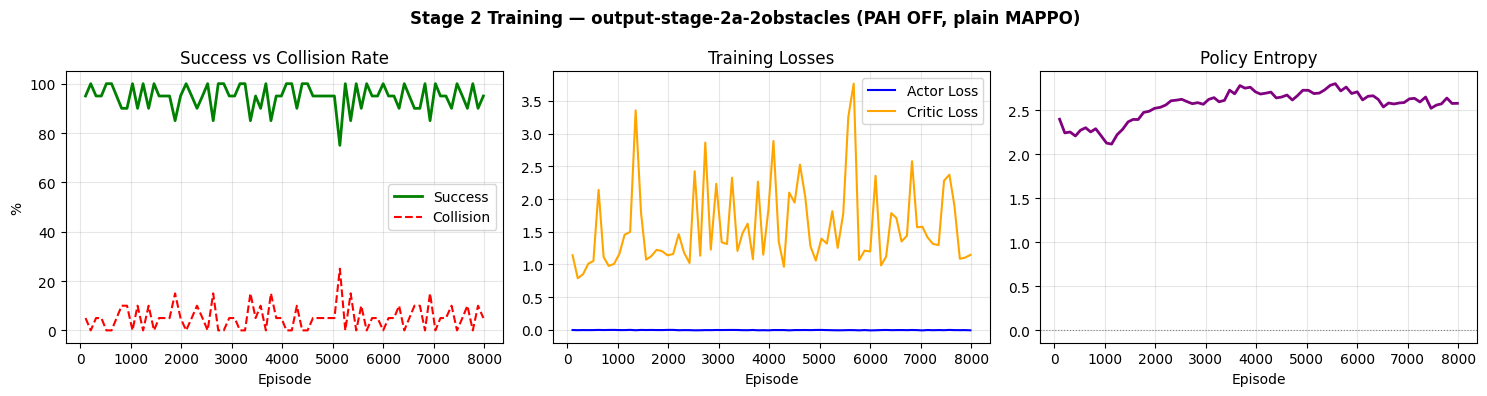

Plot saved.


In [7]:
# Cell 7 — Results Plot

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Stage 2 Training — {CFG["run_name"]} (PAH OFF, plain MAPPO)', fontweight='bold')

axes[0].plot(history['episode'], [s*100 for s in history['success']], color='green', linewidth=2, label='Success')
axes[0].plot(history['episode'], [c*100 for c in history['collision']], 'r--', linewidth=1.5, label='Collision')
axes[0].set_title('Success vs Collision Rate')
axes[0].set_ylabel('%'); axes[0].set_xlabel('Episode')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['episode'], history['actor_loss'],  color='blue',   label='Actor Loss')
axes[1].plot(history['episode'], history['critic_loss'], color='orange',  label='Critic Loss')
axes[1].set_title('Training Losses')
axes[1].set_xlabel('Episode')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['episode'], history['entropy'], color='purple', linewidth=2)
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[2].set_title('Policy Entropy')
axes[2].set_xlabel('Episode')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')